In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
    compute_variance,
    put_fig_letter,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
L4_dir = {
    "L4_noswot_regional": "/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/regional-europe/dt-grids/all-sat-merged/2023/*.nc",
    "L4_noswot_global": "/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/global/dt-grids/all-sat-merged/2023/*.nc",
    "L4_withnadirswot": "/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/*/*.nc",
}

time_window = slice(pd.to_datetime("2023-03-25"), pd.to_datetime("2023-07-15"))
longitude_window = slice(0, 7)
latitude_window = slice(36, 44)

In [3]:
L4_key = "L4_noswot_regional"
ds = xr.open_dataset(
    os.path.join(zarr_dir, "before_coloc", "L4_sealevel", L4_key + ".nc")
)

In [58]:
bbox = [4.3, 7, 39.95, 42]
# bbox = [3, 10, 30.5, 43.7]

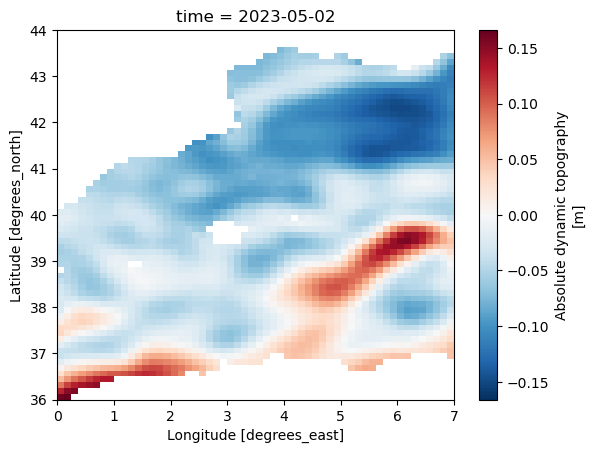

In [59]:
ds.isel(time=38).adt.plot()

In [60]:
ds_ = ds.isel(time=38).sel(
    longitude=slice(bbox[0], bbox[1]), latitude=slice(bbox[2], bbox[3])
)

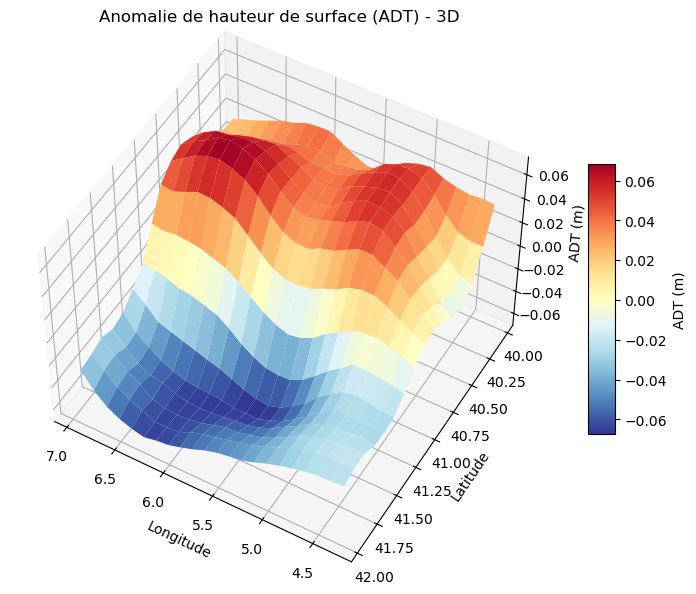

In [78]:
from mpl_toolkits.mplot3d import Axes3D

# Sélection d'une seule frame temporelle et extraction des données
adt = ds_.adt
adt = adt - adt.mean()
x = adt["longitude"]  # ou le nom de ta coordonnée longitude
y = adt["latitude"]  # ou le nom de ta coordonnée latitude
X, Y = np.meshgrid(x, y)
Z = adt.values

# Création du plot 3D
fig = plt.figure(figsize=(10, 7), frameon=False)
ax = fig.add_subplot(111, projection="3d")

# Surface avec cmap ('RdYlBu_r' = rouge haut, bleu bas)
surf = ax.plot_surface(X, Y, Z, cmap="RdYlBu_r", linewidth=0, antialiased=True)

# Barre de couleur
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="ADT (m)")

# Titres et labels
ax.set_title("Anomalie de hauteur de surface (ADT) - 3D")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("ADT (m)")

# 🎯 Orientation de la vue
ax.view_init(elev=50, azim=120)
# ax.set_axis_off()

fig.patch.set_alpha(0.0)  # Fond de la figure transparent
ax.patch.set_alpha(0.0)
plt.show()

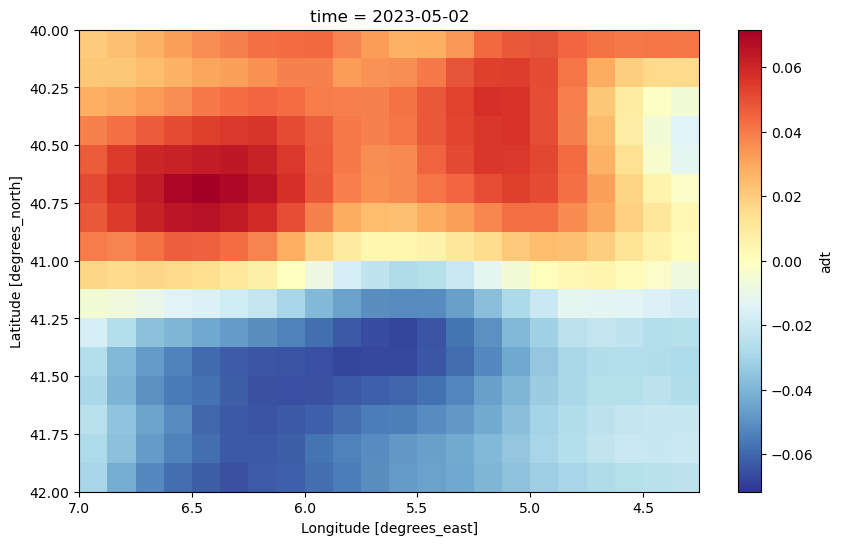

In [80]:
fig, ax = plt.subplots(frameon=False, figsize=(10, 6))
im = adt.plot(cmap="RdYlBu_r", ax=ax)

fig.gca().invert_xaxis()
fig.gca().invert_yaxis()  # souvent pour les latitudes en carte

plt.show()

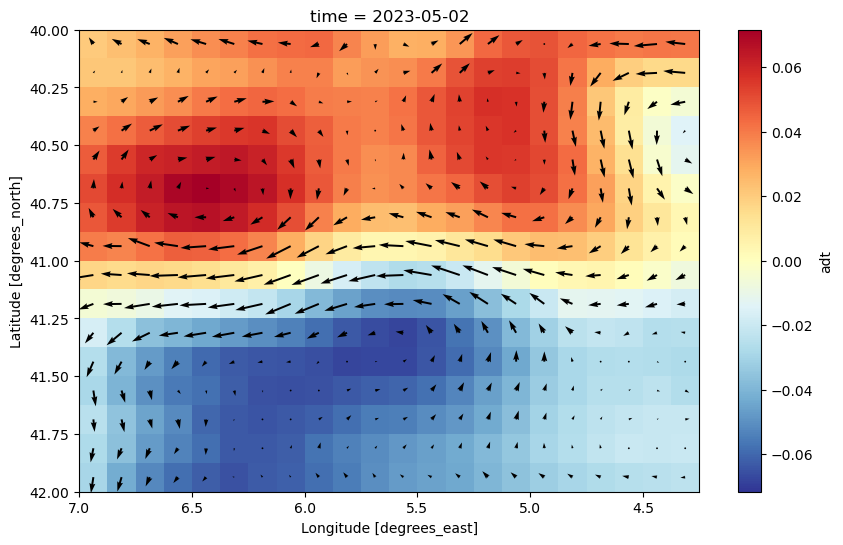

In [79]:
fig, ax = plt.subplots(frameon=False, figsize=(10, 6))
im = adt.plot(cmap="RdYlBu_r", ax=ax)

# Sous-échantillonnage pour ne pas surcharger
step = 1
x = adt["longitude"].values[::step]
y = adt["latitude"].values[::step]
X, Y = np.meshgrid(x, y)

# Vitesses
U = -ds_.ugos.values[::step, ::step]
V = -ds_.vgos.values[::step, ::step]

# Ajouter les flèches
ax.quiver(X, Y, U, V, color="k", scale=5)  # scale ajuste la taille des flèches

# Inverser les axes si besoin
fig.gca().invert_xaxis()
fig.gca().invert_yaxis()

plt.show()

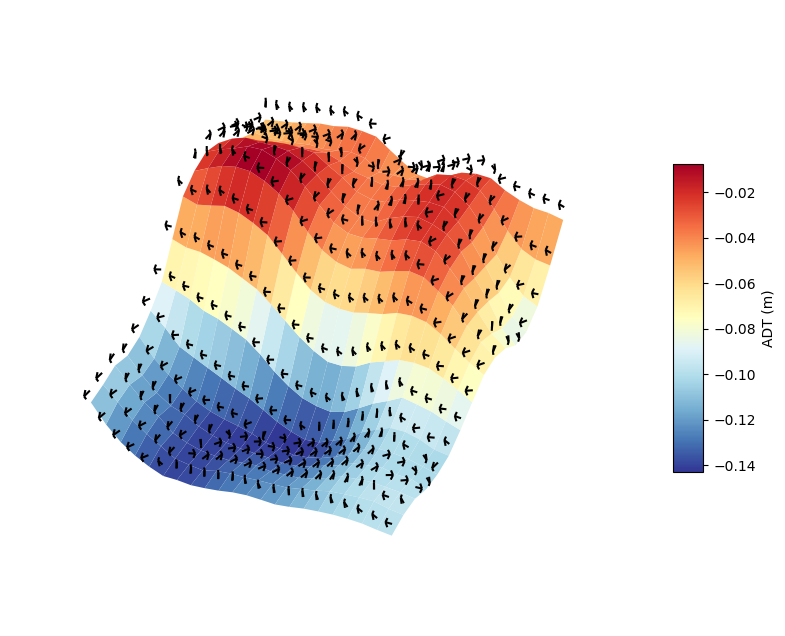

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- Données ---
adt = ds_.adt
ugos = ds_.ugos
vgos = ds_.vgos

# Coordonnées
x = adt["longitude"].values
y = adt["latitude"].values
X, Y = np.meshgrid(x, y)
Z = adt.values

# --- Sous-échantillonnage pour les flèches (sinon trop dense) ---
step = 1
Xq = X[::step, ::step]
Yq = Y[::step, ::step]
Zq = Z[::step, ::step] + 0.01  # Légère élévation pour bien voir les flèches
Uq = ugos.values[::step, ::step]
Vq = vgos.values[::step, ::step]

# --- Figure 3D ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# --- Surface ADT ---
surf = ax.plot_surface(X, Y, Z, cmap="RdYlBu_r", linewidth=0, antialiased=True)

# --- Flèches de vitesse ---
ax.quiver(
    Xq,
    Yq,
    Zq,  # position
    Uq,
    Vq,
    0,  # vecteurs (pas de composante verticale)
    length=0.05,  # taille
    color="k",  # couleur noire
    normalize=True,  # normalisation des vecteurs
)

# --- Barre de couleur ---
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="ADT (m)")

# --- Orientation et esthétique ---
ax.view_init(elev=50, azim=120)
ax.set_axis_off()
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# --- Affichage ---
plt.show()